In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score


In [ ]:
file_path = "/content/df_model_final_Clas%.xlsx"

# Cargar el dataset
df = pd.read_excel(file_path)

# Vista rápida
print("Dimensiones del dataset:", df.shape)
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(df.isna().sum())

# Balance de clases en la variable objetivo
print("\nDistribución de la variable '% beca talento final aprobada':")
print(df["% beca talento final aprobada"].value_counts(normalize=True) * 100)

Dimensiones del dataset: (2074, 18)

Columnas disponibles:
['ID_anon', 'Resultado Final', 'puntos_academicos_int', 'Pregrado al que aspiras', 'Estado de matricula', '% beca talento final aprobada', 'Entrevista', 'paso_entrevista', 'Ensayo', 'paso_ensayo', 'dependencia_economica', 'Padres_profesionales', 'log_ingresos_padres', 'puntos_estrato', 'analisis_economico', 'Edad al postularse', 'Sexo biológico', 'Dpto de Residencia']

Valores nulos por columna:
ID_anon                          0
Resultado Final                  0
puntos_academicos_int            0
Pregrado al que aspiras          0
Estado de matricula              0
% beca talento final aprobada    0
Entrevista                       0
paso_entrevista                  0
Ensayo                           0
paso_ensayo                      0
dependencia_economica            0
Padres_profesionales             0
log_ingresos_padres              0
puntos_estrato                   0
analisis_economico               0
Edad al postulars

In [ ]:
target_col = '% beca talento final aprobada'

vars_num = [
    'puntos_academicos_int',
    'Entrevista',
    'Ensayo',
    'dependencia_economica',
    'log_ingresos_padres',
    'puntos_estrato',
    'analisis_economico',
    'Edad al postularse'
]


In [ ]:
import pandas as pd

df_corr = df[[target_col] + vars_num].copy()

# matriz completa
corr_matrix = df_corr.corr()

# correlación de cada variable con la beca (ordenada)
corr_target = corr_matrix[target_col].sort_values(ascending=False)
print("Correlación de cada variable con % de beca:\n")
print(corr_target)


Correlación de cada variable con % de beca:

% beca talento final aprobada    1.000000
analisis_economico               0.581997
Entrevista                       0.200769
puntos_estrato                   0.107918
Ensayo                           0.058117
Edad al postularse               0.031585
puntos_academicos_int            0.006600
dependencia_economica           -0.118460
log_ingresos_padres             -0.188583
Name: % beca talento final aprobada, dtype: float64


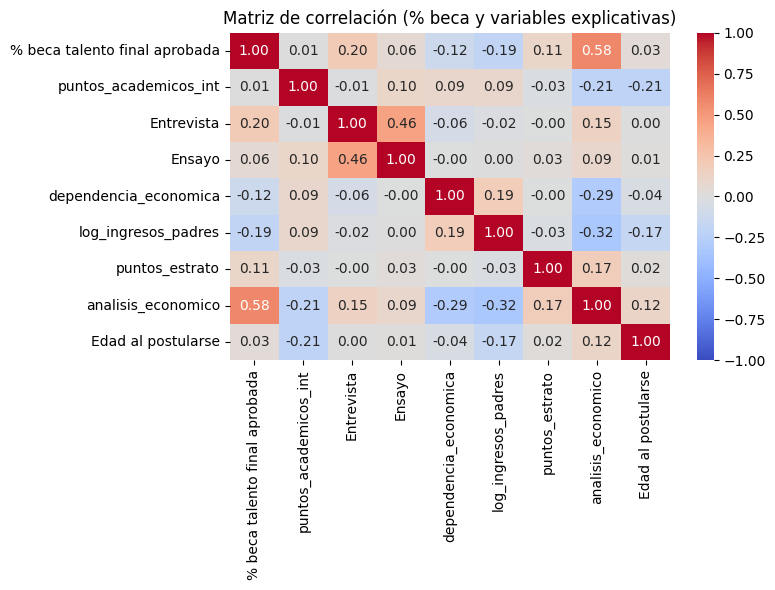

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación (% beca y variables explicativas)")
plt.tight_layout()
plt.show()


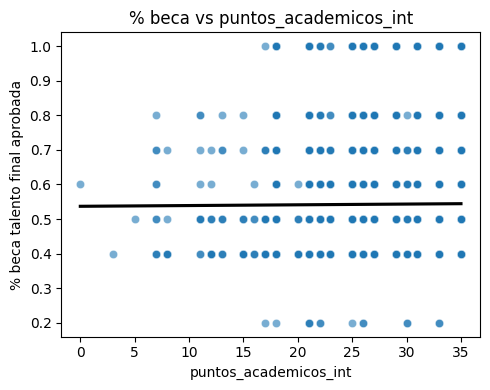

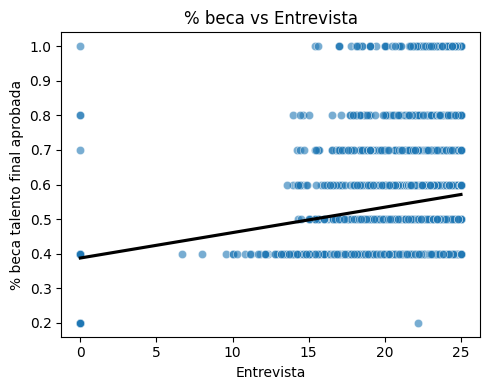

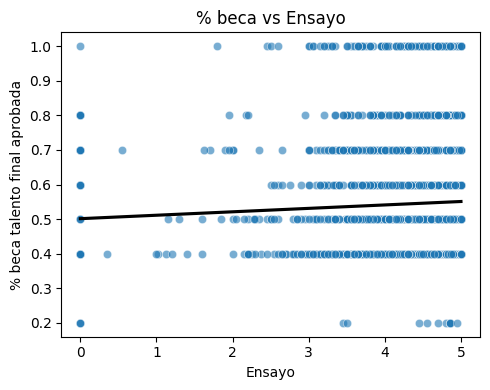

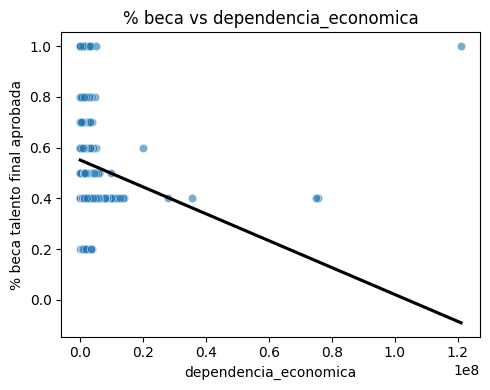

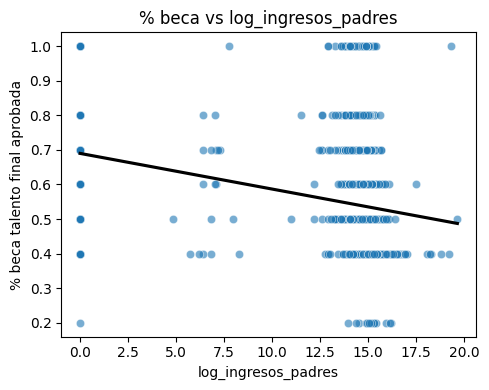

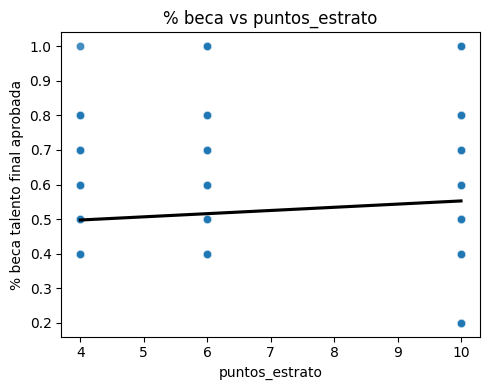

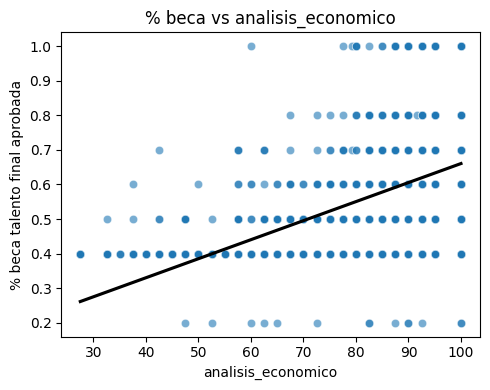

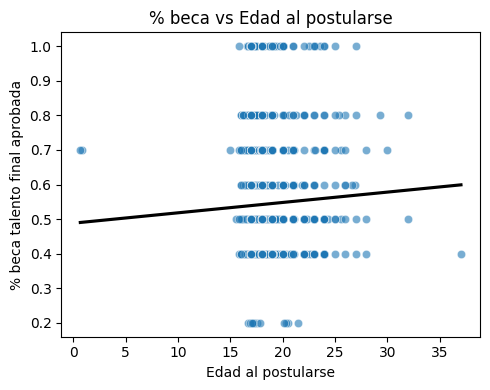

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in vars_num:
    plt.figure(figsize=(5,4))
    sns.scatterplot(data=df, x=col, y=target_col, alpha=0.6)
    sns.regplot(data=df, x=col, y=target_col,
                scatter=False, ci=None, color="black")
    plt.title(f"% beca vs {col}")
    plt.tight_layout()
    plt.show()


In [ ]:
import statsmodels.api as sm

X = df[vars_num].copy()
y = df[target_col].copy()

X = sm.add_constant(X)   # intercepto
model_lin = sm.OLS(y, X).fit()
print(model_lin.summary())


                                  OLS Regression Results                                 
Dep. Variable:     % beca talento final aprobada   R-squared:                       0.377
Model:                                       OLS   Adj. R-squared:                  0.374
Method:                            Least Squares   F-statistic:                     156.0
Date:                           Wed, 26 Nov 2025   Prob (F-statistic):          9.96e-206
Time:                                   19:39:36   Log-Likelihood:                 1125.8
No. Observations:                           2074   AIC:                            -2234.
Df Residuals:                               2065   BIC:                            -2183.
Df Model:                                      8                                         
Covariance Type:                       nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
----------